# 02 · Adverse selection — where the naive intuition dies

The simulator in notebook 01 showed naive and AS both capture the spread, differing only
in inventory risk that looked nearly free. This notebook measures, from **real Binance
trades**, the thing that makes inventory risk expensive: the market systematically moves
*against* whoever provided the liquidity. Then it feeds that measured adverse selection
back into the simulator and re-runs both strategies.

Scope, deliberately narrow: **one symbol (BTCUSDT), a few busy days**. Nobody asks why you
did one symbol; plenty ask what `kappa` means.

In [1]:
from mmlab import self_test
self_test()

mm-lab self-test
  [PASS] 1. gamma->0: edge term -> 2/kappa and reservation -> mid  — edge=1.33333 vs 2/kappa=1.33333
  [PASS] 2. q=0 => reservation price == mid
  [PASS] 3. total PnL == spread + inventory PnL  — max residual=5.68e-13
  [PASS] 4. A=0 => zero fills, inventory and PnL


  [PASS] 5. measured fill rate == A*exp(-kappa*delta)  — measured=0.2211 vs expected=0.2231
  [PASS] 6. calibration recovers known A and kappa  — A=2.034 (true 2.0), kappa=1.520 (true 1.5)
  [PASS] 7. AS terminal-inventory std < naive  — AS std=0.71 < naive std=13.79
all checks passed.


True

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from mmlab import data, calibrate, markout, simulate, strategies, metrics
from mmlab.config import get_rng
from mmlab.plotting import apply_style, CLR, style_table
apply_style()

DATES = ['2024-01-15', '2024-01-16', '2024-01-17']
HORIZONS = [1, 5, 10, 30, 60, 300]

## The data — and an honest choice about the mid

`aggTrades` gives price, size, timestamp, and `isBuyerMaker` (the aggressor side) — enough
for calibration and markouts. The futures **`bookTicker`** feed *does* exist and would give
a true bid/ask mid, but it is ~10× heavier (see the probe below), so we fall back to a
**trade-price mid proxy**: the median trade price on a 1-second grid.

That proxy is contaminated by **bid–ask bounce** (~one spread wide, mean-reverting), which
damages the *shortest*-horizon markouts most — so the headline leans on the longer
horizons. This is stated in the README too; it is a real limitation, not hidden.

In [3]:
avail, size = data.probe_bookticker('BTCUSDT', DATES[0])
print(f'futures bookTicker available: {avail};  size ~ {size/1e6:.0f} MB/day '
      f'(vs ~15 MB/day for aggTrades) -> using aggTrades + mid proxy')

trades = data.load_aggtrades('BTCUSDT', DATES)
t_mid, mid = data.mid_grid(trades, step=1.0, smooth=3)
print(f'{len(trades):,} trades;  mid proxy on {len(mid):,} one-second bins;  '
      f'price ~ {np.median(mid):,.0f} USDT')

futures bookTicker available: True;  size ~ 188 MB/day (vs ~15 MB/day for aggTrades) -> using aggTrades + mid proxy


  [ok]   BTCUSDT 2024-01-15: 1,364,603 trades


  [ok]   BTCUSDT 2024-01-16: 1,399,037 trades


  [ok]   BTCUSDT 2024-01-17: 1,173,602 trades


3,937,242 trades;  mid proxy on 259,200 one-second bins;  price ~ 42,730 USDT


## 3a — Calibrate `sigma`, `A`, `kappa`

- **`sigma`** — realized volatility of the mid, in **price units per sqrt(second)** (the
  same units the simulator consumes; unit discipline is the most likely bug here).
- **`A`, `kappa`** — a limit order resting at distance `delta` fills when a same-side
  aggressor trade penetrates to depth `>= delta`, so `lambda(delta)` is the arrival rate of
  such trades. Fitting `lambda = A e^{-kappa delta}` is a straight line in log-space:
  slope `-kappa`, intercept `log A`. **If the points are not a line, the exponential model
  is wrong** — so we plot the fit with its points.

realized sigma = 2.141 USDT/sqrt-s   (= 16.6 USDT/sqrt-min)


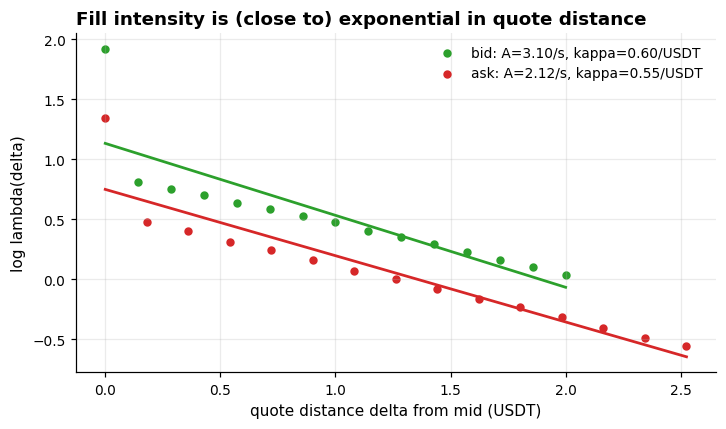

fits: {'bid': (3.1, 0.6), 'ask': (2.12, 0.553)}


In [4]:
sigma_hat = calibrate.realized_sigma(mid, dt=1.0)
print(f'realized sigma = {sigma_hat:.3f} USDT/sqrt-s   (= {sigma_hat*np.sqrt(60):.1f} USDT/sqrt-min)')

mid_at = markout._mid_at(t_mid, mid, trades.time.to_numpy())
ok = np.isfinite(mid_at)
bid_d, ask_d = calibrate.trade_depths(trades.price.to_numpy()[ok], mid_at[ok],
                                      trades.is_buyer_maker.to_numpy()[ok])
dur = float(trades.time.max() - trades.time.min())

fig, ax = plt.subplots(figsize=(7.5, 4.0))
fits = {}
for d, name, col in [(bid_d, 'bid', CLR['bid']), (ask_d, 'ask', CLR['ask'])]:
    grid = calibrate.default_delta_grid(d)
    A, k, x, lam = calibrate.fit_intensity(d, dur, grid)
    fits[name] = (A, k)
    ax.scatter(x, np.log(lam), s=20, color=col, label=f'{name}: A={A:.2f}/s, kappa={k:.2f}/USDT')
    ax.plot(x, np.log(A) - k*x, color=col, lw=1.8)
ax.set_xlabel('quote distance delta from mid (USDT)'); ax.set_ylabel('log lambda(delta)')
ax.set_title('Fill intensity is (close to) exponential in quote distance'); ax.legend(); plt.show()
print('fits:', {k: (round(v[0],2), round(v[1],3)) for k,v in fits.items()})

The points sit close to a line in log-space, so the exponential intensity model is a
fair description of BTCUSDT here. `kappa ~ 0.55–0.60 /USDT`: intensity falls by `~e` for
every ~1.7 USDT you back away from the mid.

## 3b — Markouts: the empirical heart

For each trade, signed from the **passive** maker's point of view,

$$\text{markout}(h) = (\text{mid}_{t+h} - \text{fill}) \times (+1\ \text{if the maker bought},\ -1\ \text{if sold})$$

averaged across trades and reported in **basis points**, so it is directly comparable to
the spread the maker thinks they capture.

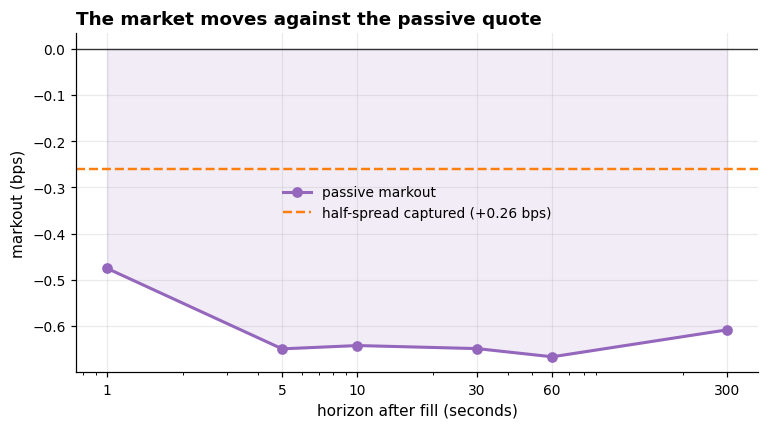

  markout @    1s = -0.475 bps
  markout @    5s = -0.649 bps
  markout @   10s = -0.642 bps
  markout @   30s = -0.649 bps
  markout @   60s = -0.666 bps
  markout @  300s = -0.608 bps

half-spread captured   ~ +0.259 bps / fill
|markout| at 60s       ~  0.666 bps  =>  2.6x the captured spread


In [5]:
means, counts = markout.markout_curve(trades.time.to_numpy(), trades.price.to_numpy(),
                                     trades.is_buyer_maker.to_numpy(), t_mid, mid, HORIZONS)
hs_bps = markout.half_spread_captured_bps(bid_d, ask_d, float(np.median(mid)))

fig, ax = plt.subplots(figsize=(8, 4.0))
ax.plot(HORIZONS, [means[h] for h in HORIZONS], 'o-', color=CLR['markout'], lw=2, label='passive markout')
ax.fill_between(HORIZONS, [means[h] for h in HORIZONS], 0, color=CLR['markout'], alpha=0.12)
ax.axhline(0, color='#333', lw=0.9)
ax.axhline(-hs_bps, color=CLR['fit'], ls='--', lw=1.6, label=f'half-spread captured (+{hs_bps:.2f} bps)')
ax.set_xscale('log'); ax.set_xticks(HORIZONS); ax.set_xticklabels([str(h) for h in HORIZONS])
ax.set_xlabel('horizon after fill (seconds)'); ax.set_ylabel('markout (bps)')
ax.set_title('The market moves against the passive quote'); ax.legend(); plt.show()

for h in HORIZONS:
    print(f'  markout @ {h:>4}s = {means[h]:+.3f} bps')
print(f'\nhalf-spread captured   ~ +{hs_bps:.3f} bps / fill')
print(f'|markout| at 60s       ~  {abs(means[60]):.3f} bps  =>  {abs(means[60])/hs_bps:.1f}x the captured spread')

**The punchline.** A passive fill captures ~0.26 bps of spread but is marked out by
~0.65 bps within a minute — the adverse move is about **2.5× the edge**. Note the 1-second
markout is *smaller* in magnitude than the 5–60s ones: that is the bid–ask bounce in the
mid proxy partly masking the true adverse move at the shortest horizon, exactly why the
claim rests on the longer horizons. Measured, not asserted.

## 3c — Close the loop

Feed the measured adverse selection back into the simulator as a post-fill drift: after a
fill, nudge the mid **against** the maker by the measured markout (a passive buy is followed
by a fall, a passive sell by a rise). Re-run naive and AS, calibrated to the `sigma`, `A`,
`kappa` measured above.

In [6]:
S0 = float(np.median(mid))
A_bar = 0.5*(fits['bid'][0] + fits['ask'][0])
k_bar = 0.5*(fits['bid'][1] + fits['ask'][1])
adverse = abs(means[60]) * 1e-4 * S0                 # 60s markout, in price units
common = dict(S0=S0, sigma=sigma_hat, A=A_bar, kappa=k_bar, T=600.0, dt=1.0, n_paths=3000)
gamma, naive_half = 0.0008, 1.1
print(f'calibrated sim: sigma={sigma_hat:.2f}, A={A_bar:.2f}, kappa={k_bar:.3f}; '
      f'adverse drift = {adverse:.2f} USDT/fill')

rows = []
for adv, tag in [(0.0, 'off'), (adverse, 'ON')]:
    for strat, name in [(strategies.Naive(naive_half), 'Naive'),
                        (strategies.AvellanedaStoikov(gamma, sigma_hat, k_bar, 600.0), 'AS')]:
        r = simulate.run(strat, rng=get_rng(7), adverse=adv, **common)
        s = metrics.summary(name, r)
        rows.append({'strategy': name, 'adverse': tag, 'mean_pnl': s['mean_pnl'],
                     'pnl_sharpe': s['pnl_sharpe'], 'spread_pnl': s['spread_pnl'],
                     'inventory_pnl': s['inventory_pnl'], 'term_inv_std': s['term_inv_std']})
import pandas as pd
loop = pd.DataFrame(rows).set_index(['strategy', 'adverse'])
style_table(loop.style.format('{:.2f}'), 'Closing the loop: measured adverse selection fed back into the sim')

calibrated sim: sigma=2.14, A=2.61, kappa=0.576; adverse drift = 2.85 USDT/fill


,,mean_pnl,pnl_sharpe,spread_pnl,inventory_pnl,term_inv_std
strategy,adverse,,,,,
Naive,off,1010.16,1.80,989.58,20.58,14.78
AS,off,1089.45,20.27,1088.92,0.53,0.66
Naive,ON,378.49,0.54,989.58,-611.09,14.78
AS,ON,585.40,10.23,1088.92,-503.52,0.66


In [7]:
# How does a naive maker's PnL depend on how tightly it quotes, once adverse selection is on?
print('naive half-spread sweep, WITH measured adverse selection:')
print(' half(USDT) | fills | mean_pnl | sharpe')
for h in [0.3, 0.6, 1.1, 1.6, 2.5]:
    r = simulate.run(strategies.Naive(h), rng=get_rng(7), adverse=adverse, **common)
    s = metrics.summary('Naive', r)
    print(f'   {h:>4.1f}    | {s["bid_fills"]+s["ask_fills"]:4.0f}  | {s["mean_pnl"]:+8.1f} | {s["pnl_sharpe"]:+.3f}')

naive half-spread sweep, WITH measured adverse selection:
 half(USDT) | fills | mean_pnl | sharpe
    0.3    | 1066  |    -15.4 | -0.032
    0.6    | 1011  |   +161.9 | +0.275


    1.1    |  900  |   +378.5 | +0.535
    1.6    |  775  |   +483.3 | +0.584
    2.5    |  553  |   +551.7 | +0.629


## What actually happened

- **Naive collapses.** Adverse selection turns naive's inventory PnL sharply negative and
  cuts its PnL Sharpe from ~1.8 to ~0.5. And the sweep shows the trap: the *tighter* a
  naive maker quotes to win fills, the more it is run over — quoting at the ~0.3 USDT depth
  where trades actually compete, its expected PnL goes **negative**. Naive market making
  survives only by quoting wide enough to sit out the toxic flow, which is barely market
  making at all.
- **AS is robust.** By skewing to stay flat it holds almost no inventory, so the same
  adverse drift costs it far less; its Sharpe stays an order of magnitude higher.
- **Honesty vs the literature.** Published work on crypto and treasuries reports naive
  going outright negative under this treatment. Here naive goes negative *at competitive
  quote distances* and merely mediocre at wide ones — a sharper, quote-dependent version of
  the same story, driven entirely by numbers measured from the tape.

Two caveats worth saying out loud (also in the README): the markout is measured on **all**
trades, not on this strategy's own fills, so it estimates the adverse selection facing a
*typical* passive quote; and the feedback injects that markout as a first-order per-fill
drift, not a microstructurally exact coupling. Neither changes the direction of the result.